<a href="https://colab.research.google.com/github/Snowpuppies2020/Finance/blob/main/NT%E5%80%8D%E7%8E%87%E3%81%AE%E5%B9%B3%E5%9D%87%E4%B9%96%E9%9B%A2%E3%83%88%E3%83%AC%E3%83%BC%E3%83%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1598/2588054083.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_n225 = yf.download('1321.T', start='2015-01-01')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1598/2588054083.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_topix = yf.download('1306.T', start='2015-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


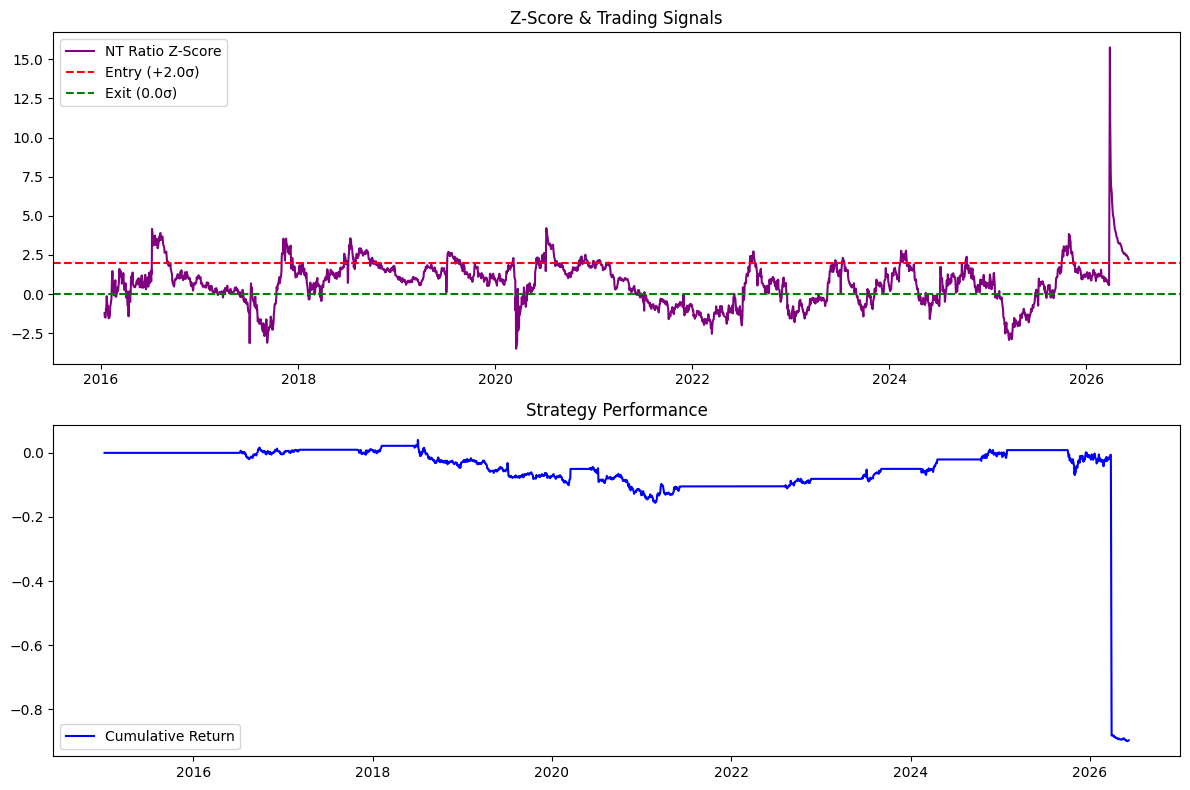

年率リターン: -18.40%
シャープレシオ: -0.34


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. データの取得 (2015年〜現在)
# 1321: 日経225 ETF, 1306: TOPIX ETF
df_n225 = yf.download('1321.T', start='2015-01-01')['Close']
df_topix = yf.download('1306.T', start='2015-01-01')['Close']

df = pd.concat([df_n225, df_topix], axis=1)
df.columns = ['N225', 'TOPIX']
df = df.dropna()

# 2. NT倍率とZスコアの計算
df['NT_Ratio'] = df['N225'] / df['TOPIX']
window = 252 # 1年移動平均

df['Mean'] = df['NT_Ratio'].rolling(window=window).mean()
df['Std'] = df['NT_Ratio'].rolling(window=window).std()
df['Z_Score'] = (df['NT_Ratio'] - df['Mean']) / df['Std']

# --- 調整可能なパラメータ ---
entry_sigma = 2.0 # エントリーシグナル (例: +2σでショート)
exit_sigma = 0.0  # エグジットシグナル (例: 0σで決済)
# --- ここまで ---

# 3. トレードシグナルの生成 (+entry_sigmaでショート、exit_sigmaで決済)
positions = np.zeros(len(df))
pos = 0
for i in range(len(df)):
    if pd.isna(df['Z_Score'].iloc[i]):
        positions[i] = 0
        continue

    z = df['Z_Score'].iloc[i]
    if z > entry_sigma:
        pos = -1 # 日経ショート / TOPIXロング
    elif pos == -1 and z < exit_sigma:
        pos = 0  # 決済
    positions[i] = pos

df['Position'] = positions

# 4. リターンの計算
df['N225_Ret'] = df['N225'].pct_change()
df['TOPIX_Ret'] = df['TOPIX'].pct_change()

# ペアトレードリターン (TOPIXロング - N225ショート)
df['Strategy_Ret'] = df['Position'].shift(1) * (df['N225_Ret'] - df['TOPIX_Ret'])
df['Cum_Ret'] = (1 + df['Strategy_Ret'].fillna(0)).cumprod() - 1

# 5. 結果のプロット
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Z_Score'], label='NT Ratio Z-Score', color='purple')
plt.axhline(entry_sigma, color='red', linestyle='--', label=f'Entry (+{entry_sigma}σ)')
plt.axhline(exit_sigma, color='green', linestyle='--', label=f'Exit ({exit_sigma}σ)')
plt.legend()
plt.title('Z-Score & Trading Signals')

plt.subplot(2, 1, 2)
plt.plot(df.index, df['Cum_Ret'], label='Cumulative Return', color='blue')
plt.title('Strategy Performance')
plt.legend()
plt.tight_layout()
plt.show()

# 6. パフォーマンス指標の出力
ann_ret = (1 + df['Cum_Ret'].iloc[-1]) ** (252 / len(df)) - 1
sharpe = np.sqrt(252) * df['Strategy_Ret'].mean() / df['Strategy_Ret'].std()
print(f"年率リターン: {ann_ret:.2%}")
print(f"シャープレシオ: {sharpe:.2f}")

### パラメータ最適化

`entry_sigma`と`exit_sigma`の範囲を探索し、最も高い年率リターンが得られる条件を見つけます。

In [4]:
# 最適化パラメータの範囲を定義
entry_sigmas = np.arange(0.5, 3.1, 0.25) # 例: 0.5から3.0まで0.25刻み
exit_sigmas = np.arange(-1.0, 1.1, 0.25)  # 例: -1.0から1.0まで0.25刻み

best_ann_ret = -np.inf
best_entry_sigma = None
best_exit_sigma = None

results = []

for entry_s in entry_sigmas:
    for exit_s in exit_sigmas:
        # 3. トレードシグナルの生成 (+entry_sigmaでショート、exit_sigmaで決済)
        positions_opt = np.zeros(len(df))
        pos_opt = 0
        for i in range(len(df)):
            if pd.isna(df['Z_Score'].iloc[i]):
                positions_opt[i] = 0
                continue

            z_opt = df['Z_Score'].iloc[i]
            if z_opt > entry_s:
                pos_opt = -1 # 日経ショート / TOPIXロング
            elif pos_opt == -1 and z_opt < exit_s:
                pos_opt = 0  # 決済
            positions_opt[i] = pos_opt

        df['Position_Opt'] = positions_opt

        # 4. リターンの計算
        # ペアトレードリターン (TOPIXロング - N225ショート)
        df['Strategy_Ret_Opt'] = df['Position_Opt'].shift(1) * (df['N225_Ret'] - df['TOPIX_Ret'])
        df['Cum_Ret_Opt'] = (1 + df['Strategy_Ret_Opt'].fillna(0)).cumprod() - 1

        # 6. パフォーマンス指標の出力
        if not df['Cum_Ret_Opt'].empty:
            current_ann_ret = (1 + df['Cum_Ret_Opt'].iloc[-1]) ** (252 / len(df)) - 1
            current_sharpe = np.sqrt(252) * df['Strategy_Ret_Opt'].mean() / df['Strategy_Ret_Opt'].std()
        else:
            current_ann_ret = -np.inf # If no trades, treat as worst case
            current_sharpe = -np.inf

        results.append({
            'entry_sigma': entry_s,
            'exit_sigma': exit_s,
            'annual_return': current_ann_ret,
            'sharpe_ratio': current_sharpe
        })

        if current_ann_ret > best_ann_ret:
            best_ann_ret = current_ann_ret
            best_entry_sigma = entry_s
            best_exit_sigma = exit_s

# 結果の表示
print(f"最適なエントリーシグマ: {best_entry_sigma:.2f}")
print(f"最適なエグジットシグマ: {best_exit_sigma:.2f}")
print(f"最大年率リターン: {best_ann_ret:.2%}")

# 全ての結果をDataFrameで表示
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='annual_return', ascending=False).head())


最適なエントリーシグマ: 1.25
最適なエグジットシグマ: 1.00
最大年率リターン: -0.11%


,entry_sigma,exit_sigma,annual_return,sharpe_ratio
35,1.25,1.00,-0.001065,0.001514
70,2.25,0.75,-0.002561,-0.033408
44,1.50,1.00,-0.002669,-0.035467
26,1.00,1.00,-0.002930,-0.034550
34,1.25,0.75,-0.004124,-0.055227
